In [ ]:
# ============================================================
# Importing necessary libraries and setting up the environment for data analysis and visualization.
# ============================================================

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Imports successful")

✓ Imports successful


In [ ]:
# ============================================================
# Data Loading and Initial Exploration
# ============================================================

# Data loading
df = pd.read_csv('../data/processed/dataset.csv')

# Data type conversion
df['start_time'] = pd.to_datetime(df['start_time'])

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\n Dataset shape: {df.shape}")
print(f"  Samples: {len(df):,}")
print(f"  Features: {df.shape[1]}")

print(f"\n Date range:")
print(f"  From: {df['start_time'].min().date()}")
print(f"  To: {df['start_time'].max().date()}")
print(f"  Duration: {(df['start_time'].max() - df['start_time'].min()).days} days")

print(f"\n Target variable distribution:")
print(f"  Result = 1: {df['is_result'].sum():,} ({df['is_result'].mean():.2%})")
print(f"  Result = 0: {(df['is_result'] == 0).sum():,} ({(df['is_result'] == 0).mean():.2%})")

print(f"\n Data types:")
print(df.dtypes)

DATASET OVERVIEW

 Dataset shape: (79876, 20)
  Samples: 79,876
  Features: 20

 Date range:
  From: 2024-10-01
  To: 2025-03-15
  Duration: 165 days

 Target variable distribution:
  Result = 1: 7,127.0 (8.92%)
  Result = 0: 72,749 (91.08%)

 Data types:
call_id                             object
client_dwh_id                        int64
sieb_id                              int64
is_result                          float64
client_call_number                   int64
client_prev_result_rate            float64
client_prev_contact_rate           float64
days_since_last_call               float64
start_time                  datetime64[ns]
hour                                 int64
day_of_week                          int64
is_weekend                           int64
region                              object
age_group                           object
debt_amount_bucket                  object
product_type                        object
preferred_language                  object
risk_score   

In [ ]:
# ============================================================
# Checking for Missing Values
# ============================================================

print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print("\n  Missing values detected:\n")
    print(missing_df)
else:
    print("\n✓ No missing values")

MISSING VALUES CHECK

✓ No missing values


TARGET VARIABLE ANALYSIS


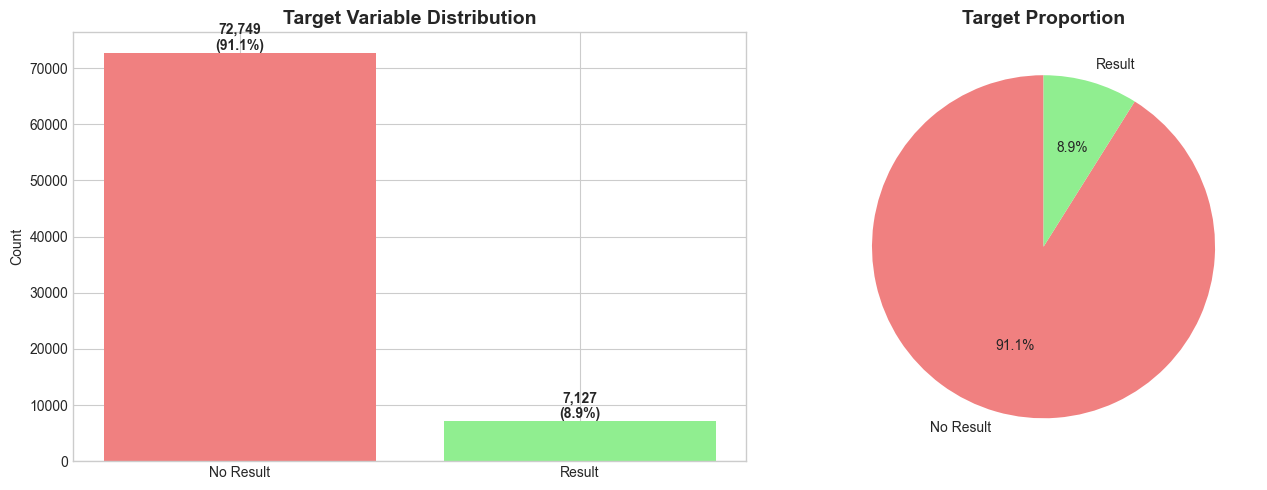


 Class Imbalance Ratio: 1:10.2


In [ ]:
# ============================================================
# Target Variable Distribution
# ============================================================

print("=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Подсчёт
target_counts = df['is_result'].value_counts()

# Bar plot
axes[0].bar(['No Result', 'Result'], target_counts.values, color=['lightcoral', 'lightgreen'])
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df):.1%})', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Result', 'Result'], autopct='%1.1f%%', 
            colors=['lightcoral', 'lightgreen'], startangle=90)
axes[1].set_title('Target Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Class Imbalance Ratio: 1:{(df['is_result'] == 0).sum() / df['is_result'].sum():.1f}")

NUMERICAL FEATURES DISTRIBUTION


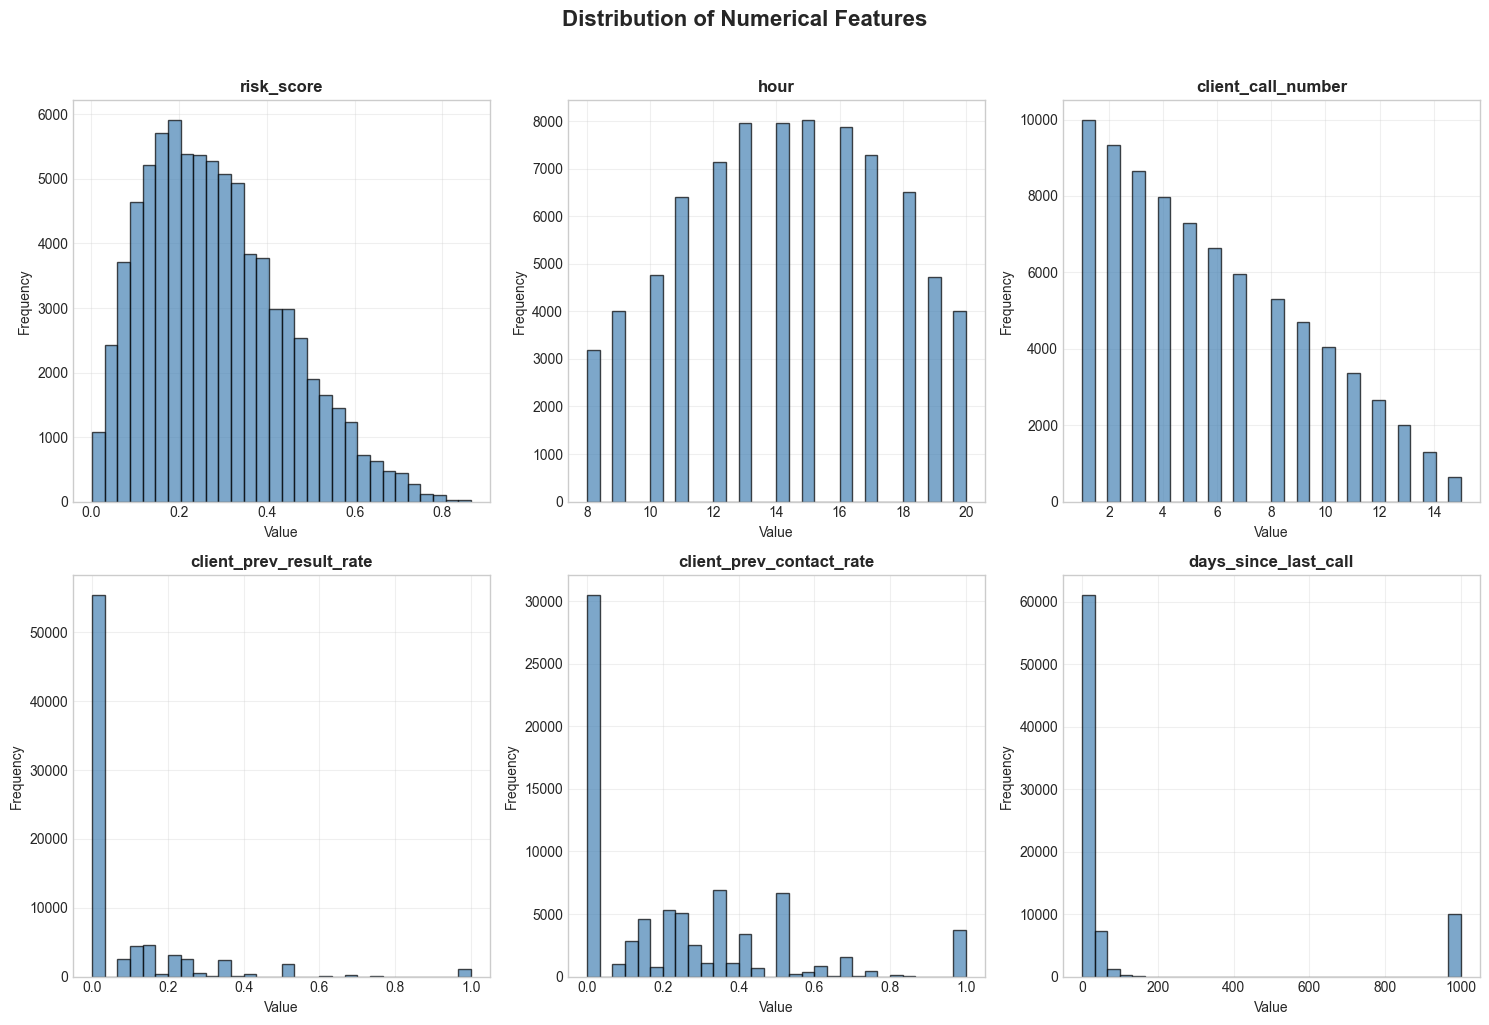


 Numerical Features Statistics:

                            count        mean         std       min  \
risk_score                79876.0    0.284183    0.157899  0.002798   
hour                      79876.0   14.247146    3.266527  8.000000   
client_call_number        79876.0    5.667159    3.636151  1.000000   
client_prev_result_rate   79876.0    0.077302    0.161884  0.000000   
client_prev_contact_rate  79876.0    0.232091    0.257995  0.000000   
days_since_last_call      79876.0  139.246743  325.648219  0.000093   

                                25%        50%        75%        max  
risk_score                 0.161534   0.263174   0.385315    0.86494  
hour                      12.000000  14.000000  17.000000   20.00000  
client_call_number         3.000000   5.000000   8.000000   15.00000  
client_prev_result_rate    0.000000   0.000000   0.111111    1.00000  
client_prev_contact_rate   0.000000   0.200000   0.333333    1.00000  
days_since_last_call       5.132069  13.14

In [9]:
# ============================================================
# Distribution of Numerical Features
# ============================================================

print("=" * 60)
print("NUMERICAL FEATURES DISTRIBUTION")
print("=" * 60)

numerical_features = [
    'risk_score', 'hour', 'client_call_number', 
    'client_prev_result_rate', 'client_prev_contact_rate', 
    'days_since_last_call'
]

# Exclude features that are not present in the dataset
numerical_features = [f for f in numerical_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    if i < len(axes):
        axes[i].hist(df[feature].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)

# Show only the subplots for existing features, hide the rest
for i in range(len(numerical_features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics for numerical features
print("\n Numerical Features Statistics:\n")
print(df[numerical_features].describe().T)

CATEGORICAL FEATURES DISTRIBUTION


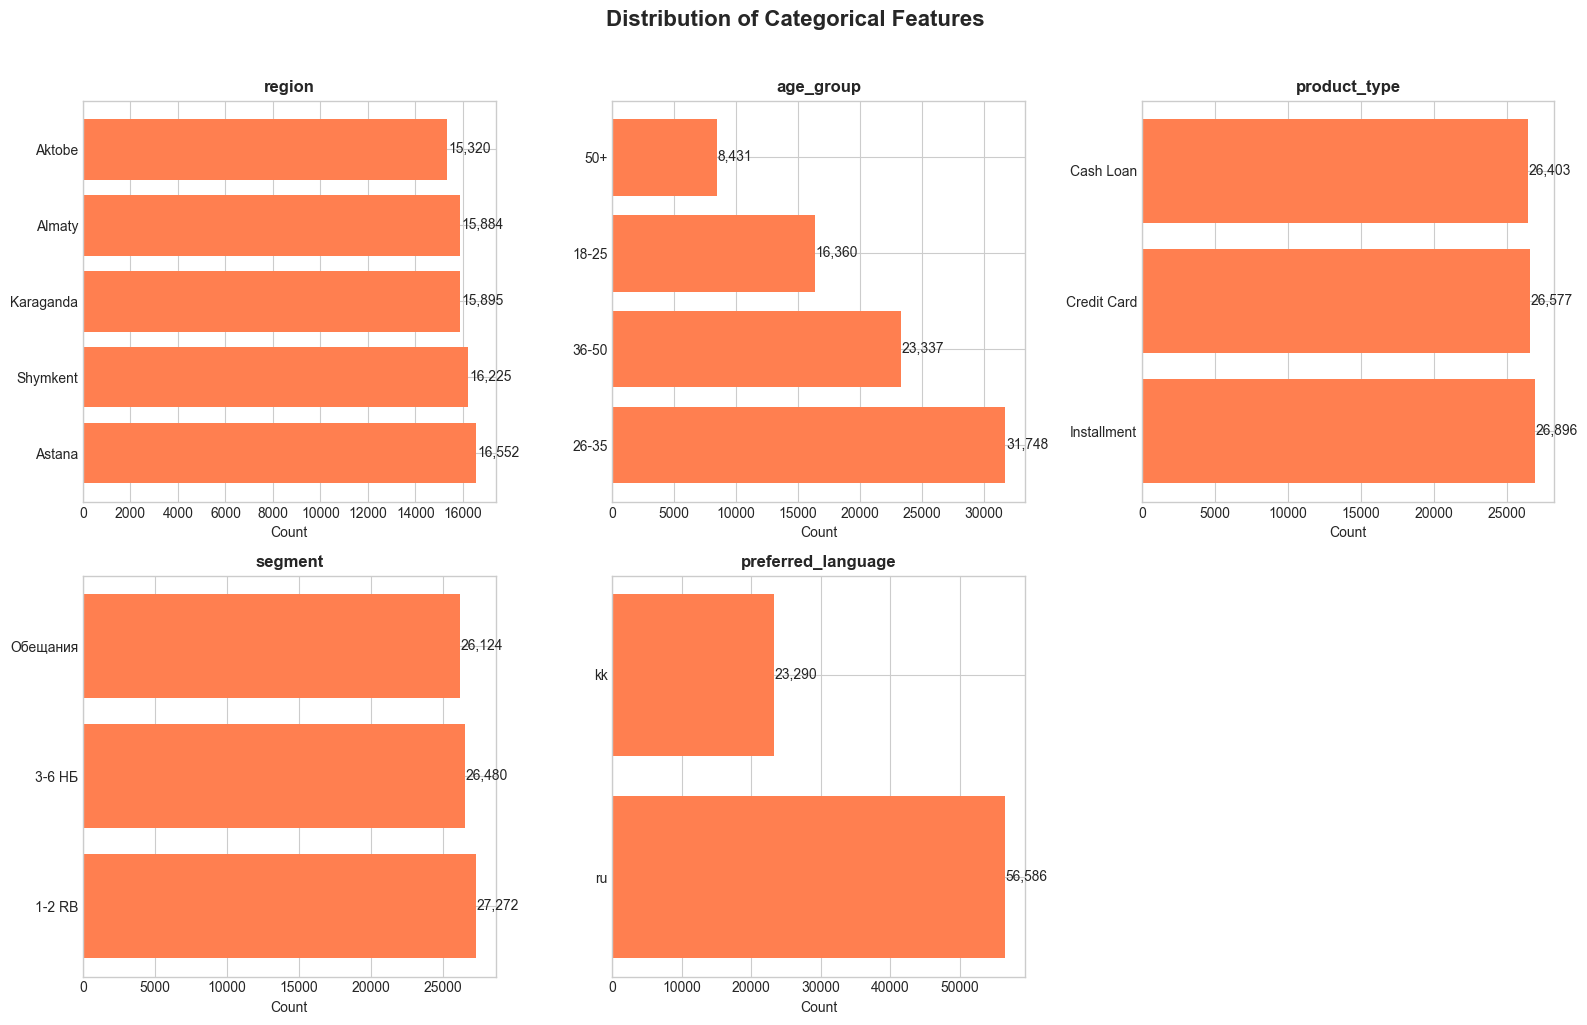

In [10]:
# ============================================================
# Distribution of Categorical Features
# ============================================================

print("=" * 60)
print("CATEGORICAL FEATURES DISTRIBUTION")
print("=" * 60)

categorical_features = ['region', 'age_group', 'product_type', 'segment', 'preferred_language']
categorical_features = [f for f in categorical_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    if i < len(axes):
        value_counts = df[feature].value_counts()
        axes[i].barh(range(len(value_counts)), value_counts.values, color='coral')
        axes[i].set_yticks(range(len(value_counts)))
        axes[i].set_yticklabels(value_counts.index)
        axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Count')
        
        # Добавляем значения на столбцы
        for j, v in enumerate(value_counts.values):
            axes[i].text(v + 50, j, f'{v:,}', va='center')

for i in range(len(categorical_features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

FEATURE vs TARGET ANALYSIS


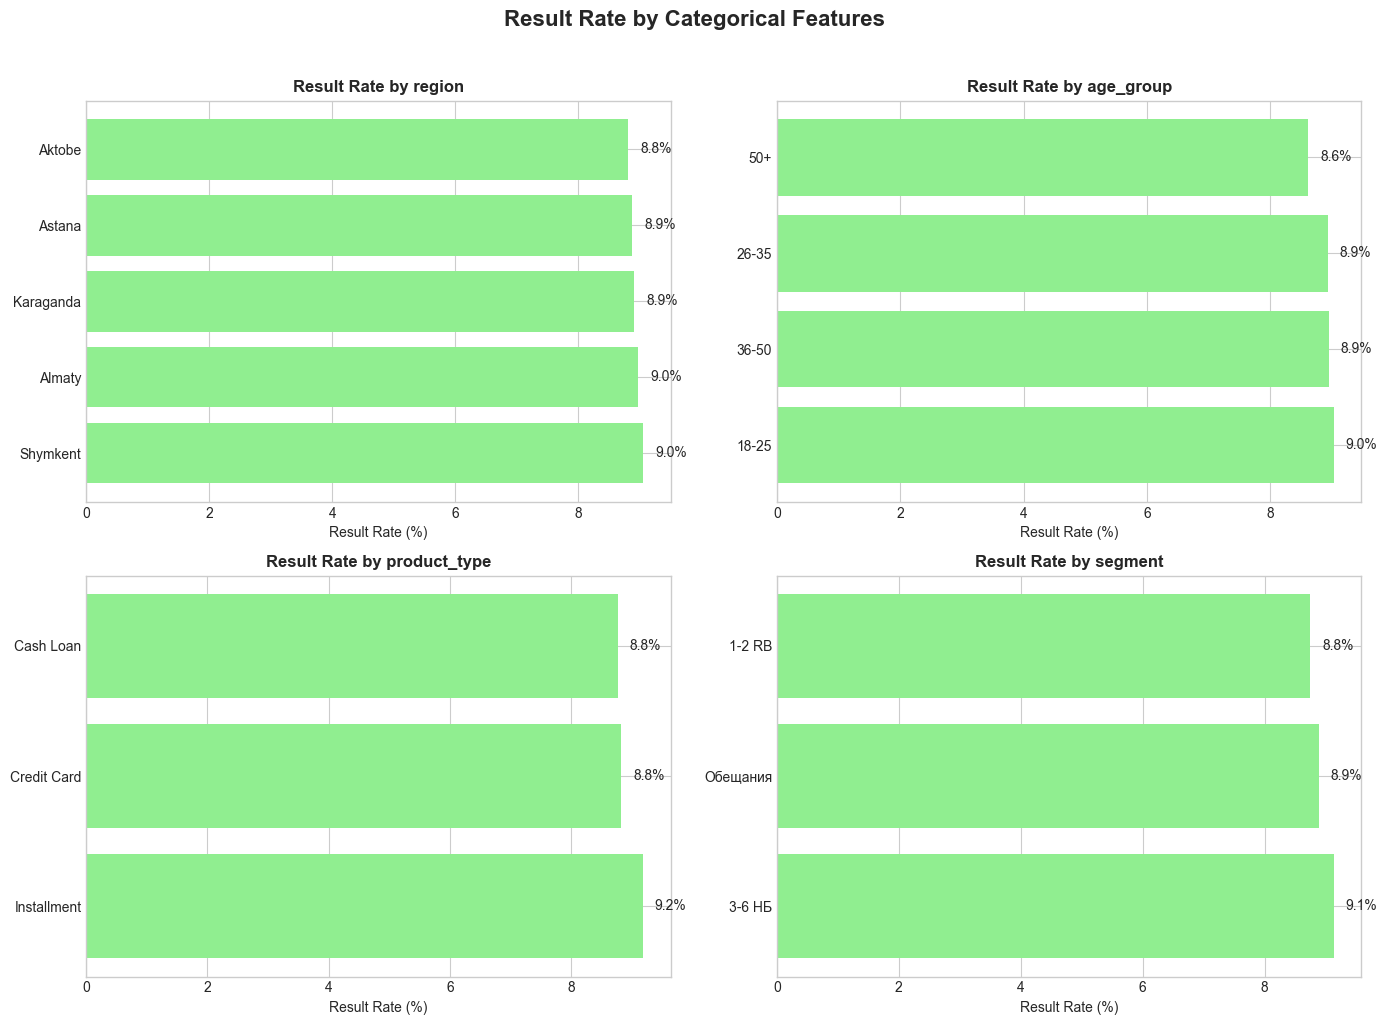


 Result Rate by Feature:


region:
           Results  Total   Rate
region                          
Aktobe      1349.0  15320  0.088
Almaty      1426.0  15884  0.090
Astana      1469.0  16552  0.089
Karaganda   1415.0  15895  0.089
Shymkent    1468.0  16225  0.090

age_group:
           Results  Total   Rate
age_group                       
18-25       1477.0  16360  0.090
26-35       2836.0  31748  0.089
36-50       2088.0  23337  0.089
50+          726.0   8431  0.086

product_type:
              Results  Total   Rate
product_type                       
Cash Loan      2314.0  26403  0.088
Credit Card    2344.0  26577  0.088
Installment    2469.0  26896  0.092

segment:
          Results  Total   Rate
segment                        
1-2 RB     2387.0  27272  0.088
3-6 НБ     2418.0  26480  0.091
Обещания   2322.0  26124  0.089


In [11]:
# ============================================================
# Feature vs Target Analysis
# ============================================================

print("=" * 60)
print("FEATURE vs TARGET ANALYSIS")
print("=" * 60)

# Result rate by categorical features
categorical_features = ['region', 'age_group', 'product_type', 'segment']
categorical_features = [f for f in categorical_features if f in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    if i < len(axes):
        result_rate = df.groupby(feature)['is_result'].mean().sort_values(ascending=False)
        
        axes[i].barh(range(len(result_rate)), result_rate.values * 100, color='lightgreen')
        axes[i].set_yticks(range(len(result_rate)))
        axes[i].set_yticklabels(result_rate.index)
        axes[i].set_title(f'Result Rate by {feature}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Result Rate (%)')
        
        for j, v in enumerate(result_rate.values):
            axes[i].text(v * 100 + 0.2, j, f'{v:.1%}', va='center')

plt.suptitle('Result Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Detailed statistics for result rate by categorical features
print("\n Result Rate by Feature:\n")
for feature in categorical_features:
    print(f"\n{feature}:")
    result_stats = df.groupby(feature).agg({
        'is_result': ['sum', 'count', 'mean']
    }).round(3)
    result_stats.columns = ['Results', 'Total', 'Rate']
    print(result_stats)

TEMPORAL PATTERNS


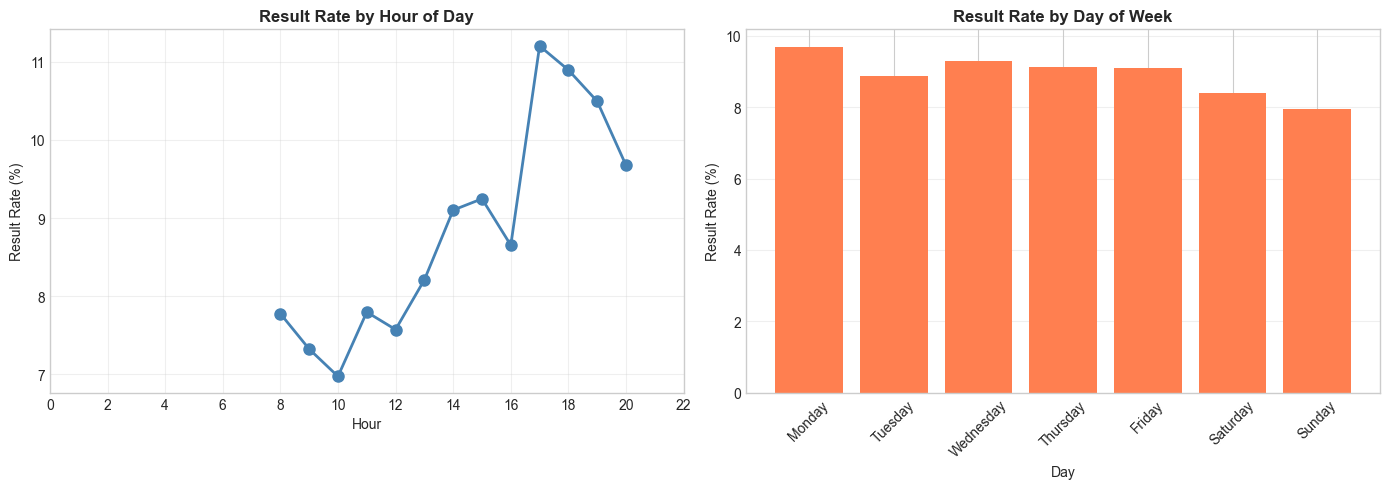


 Hourly Statistics:
      Results  Calls  Result_Rate
hour                             
8       248.0   3189     0.077767
9       293.0   4001     0.073232
10      332.0   4761     0.069733
11      500.0   6413     0.077967
12      541.0   7144     0.075728
13      653.0   7954     0.082097
14      725.0   7965     0.091023
15      743.0   8035     0.092470
16      681.0   7870     0.086531
17      817.0   7292     0.112041
18      710.0   6516     0.108963
19      496.0   4726     0.104951
20      388.0   4010     0.096758

 Daily Statistics:
             Results  Calls  Result_Rate
day_of_week                             
Monday        1088.0  11229     0.096892
Tuesday       1042.0  11735     0.088794
Wednesday     1076.0  11583     0.092895
Thursday      1039.0  11373     0.091357
Friday        1042.0  11443     0.091060
Saturday       976.0  11638     0.083863
Sunday         864.0  10875     0.079448


In [12]:
# ============================================================
# Temporal Patterns
# ============================================================

print("=" * 60)
print("TEMPORAL PATTERNS")
print("=" * 60)

# Adding temporal features
df['date'] = df['start_time'].dt.date
df['day_of_week'] = df['start_time'].dt.day_name()
df['is_weekend'] = df['start_time'].dt.dayofweek >= 5

# Result rate by hours
hourly_stats = df.groupby('hour').agg({
    'is_result': ['sum', 'count', 'mean']
})
hourly_stats.columns = ['Results', 'Calls', 'Result_Rate']

# Result rate by days of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats = df.groupby('day_of_week').agg({
    'is_result': ['sum', 'count', 'mean']
})
daily_stats.columns = ['Results', 'Calls', 'Result_Rate']
daily_stats = daily_stats.reindex(day_order)

# Visualization of temporal patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By hours
axes[0].plot(hourly_stats.index, hourly_stats['Result_Rate'] * 100, 
             marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_title('Result Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Result Rate (%)')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# By days of week
axes[1].bar(range(len(daily_stats)), daily_stats['Result_Rate'] * 100, color='coral')
axes[1].set_title('Result Rate by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Result Rate (%)')
axes[1].set_xticks(range(len(daily_stats)))
axes[1].set_xticklabels(daily_stats.index, rotation=45)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Hourly Statistics:")
print(hourly_stats)

print("\n Daily Statistics:")
print(daily_stats)

FEATURE CORRELATIONS


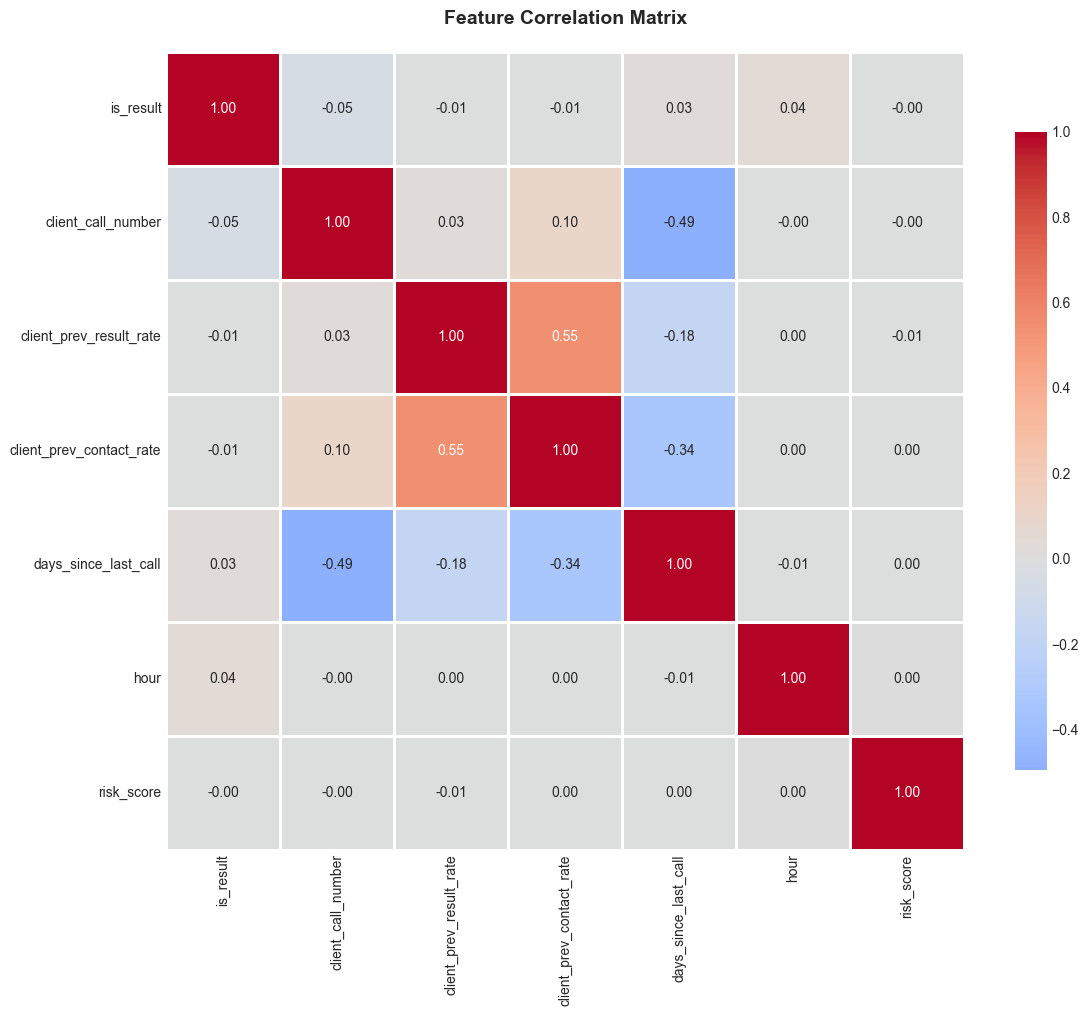


 Correlation with Target (is_result):

is_result                   1.000000
hour                        0.039347
days_since_last_call        0.028966
risk_score                 -0.004850
client_prev_result_rate    -0.005294
client_prev_contact_rate   -0.007839
client_call_number         -0.047525
Name: is_result, dtype: float64


In [13]:
# ============================================================
# Feature Correlation Matrix (Numerical Features)
# ============================================================

print("=" * 60)
print("FEATURE CORRELATIONS")
print("=" * 60)

# Choosing numerical features for correlation analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Excluding ID and timestamp features
numerical_cols = [col for col in numerical_cols 
                  if col not in ['client_dwh_id', 'sieb_id', 'call_id', 'start_time']]

# Correlation matrix
corr_matrix = df[numerical_cols].corr()

# Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation with target variable
print("\n Correlation with Target (is_result):\n")
target_corr = corr_matrix['is_result'].sort_values(ascending=False)
print(target_corr)

In [14]:
# ============================================================
# Key Insights
# ============================================================

print("=" * 60)
print("KEY INSIGHTS FROM EDA")
print("=" * 60)

insights = []

# 1. Class imbalance
imbalance_ratio = (df['is_result'] == 0).sum() / df['is_result'].sum()
insights.append(f"1. Class Imbalance: {imbalance_ratio:.1f}:1 (Non-result : Result)")

# 2. Best hour for calls
best_hour = hourly_stats['Result_Rate'].idxmax()
best_hour_rate = hourly_stats['Result_Rate'].max()
insights.append(f"2. Best Hour: {best_hour}:00 (Result Rate: {best_hour_rate:.2%})")

# 3. Best day of the week
best_day = daily_stats['Result_Rate'].idxmax()
best_day_rate = daily_stats['Result_Rate'].max()
insights.append(f"3. Best Day: {best_day} (Result Rate: {best_day_rate:.2%})")

# 4. Call attempt number
if 'client_call_number' in df.columns:
    first_call_rate = df[df['client_call_number'] == 1]['is_result'].mean()
    later_call_rate = df[df['client_call_number'] > 1]['is_result'].mean()
    insights.append(f"4. First Call Success: {first_call_rate:.2%} vs Later Calls: {later_call_rate:.2%}")

# 5. Best segment
if 'segment' in df.columns:
    best_segment = df.groupby('segment')['is_result'].mean().idxmax()
    best_segment_rate = df.groupby('segment')['is_result'].mean().max()
    insights.append(f"5. Best Segment: {best_segment} (Result Rate: {best_segment_rate:.2%})")

print("\n Key Findings:\n")
for insight in insights:
    print(f"  {insight}")

print("\n" + "=" * 60)
print("✓✓✓ EDA COMPLETE ✓✓✓")
print("=" * 60)

KEY INSIGHTS FROM EDA

 Key Findings:

  1. Class Imbalance: 10.2:1 (Non-result : Result)
  2. Best Hour: 17:00 (Result Rate: 11.20%)
  3. Best Day: Monday (Result Rate: 9.69%)
  4. First Call Success: 10.97% vs Later Calls: 8.63%
  5. Best Segment: 3-6 НБ (Result Rate: 9.13%)

✓✓✓ EDA COMPLETE ✓✓✓
